# 📊 Analisis Faktor-Faktor Penjualan Produk E-Commerce
**Metode:** Regresi Linear Berganda (*Multiple Linear Regression*)  
**Dataset:** Tokopedia Products Dataset (Sumber: Repositori Publik Kaggle, 2025)  
**Total Data:** 1.200 Baris Data Riil  
**Target Prediksi:** Jumlah Penjualan (*Sold Count*)  

---
*Proyek ini bertujuan untuk menguji secara statistik seberapa besar pengaruh Harga, Persentase Diskon, dan Jumlah Ulasan terhadap total penjualan suatu produk di platform e-commerce.*

In [90]:
# ==============================================================================
# ANALISIS FAKTOR-FAKTOR YANG MEMPENGARUHI JUMLAH PENJUALAN PRODUK TOKOPEDIA
# MENGGUNAKAN REGRESI LINEAR BERGANDA
#
# Dataset : Tokopedia Products Dataset 2025
# Jumlah Data : 1200 Produk
# ==============================================================================

print("ANALISIS FAKTOR-FAKTOR YANG MEMPENGARUHI JUMLAH PENJUALAN PRODUK TOKOPEDIA")

ANALISIS FAKTOR-FAKTOR YANG MEMPENGARUHI JUMLAH PENJUALAN PRODUK TOKOPEDIA


In [91]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

In [92]:
df = pd.read_csv("../dataset/products.csv")

print("Jumlah Data :", len(df))

Jumlah Data : 1200


In [93]:
df.head()

,id,name,description,min_order,max_order,weight,weight_unit,condition,status,applink,...,category_name,category_url,transaction_success,transaction_reject,sold_count,sold_count_text,view_count,review_count,talk_count,rating
0,102029588821,[ONLINE EXCLUSIVE] vivo iQOO Z9 5G Snapdragon ...,NaN,1,0,300,Gram,New,Active,tokopedia://product/102029588821,...,Android OS,https://www.tokopedia.com/p/handphone-tablet/h...,0,0,3817,3 rb+,0,988,0,4.9
1,100432934805,Paket Bundle Your Coffee Your Choice Exclusive...,"Halo, Sobat Brewer! 🌟\n\n\nSakha Coffee saat i...",1,5475,465,Gram,New,Active,tokopedia://product/100432934805,...,Kopi,https://www.tokopedia.com/p/makanan-minuman/mi...,0,0,1171,1 rb+,0,346,0,5.0
2,10520453151,"Sweety Bronze Dry X-Pert Pants S, M, L, XL & X...",Popok bayi Sweety Bronze Dry X-Pert Pants hadi...,1,55,1100,Gram,New,Active,tokopedia://product/10520453151,...,Popok Sekali Pakai,https://www.tokopedia.com/p/ibu-bayi/popok/pop...,0,0,3781,3 rb+,0,484,0,4.9
3,100290184021,[Free Bantal] INTHEBOX ALPHA X - Kasur Springb...,"Kasur INTHEBOX Alpha X ialah kasur spring bed,...",1,45,32000,Gram,New,Active,tokopedia://product/100290184021,...,Kasur,https://www.tokopedia.com/p/rumah-tangga/furni...,0,0,51292,50 rb+,0,7763,0,4.8
4,10850469296,"GOOJODOQ 15,6"" FHD 1080P Portable Monitor for ...",GOOJODOQ - Focus on Paperless Office\n\nBrilli...,1,47,2000,Gram,New,Active,tokopedia://product/10850469296,...,Monitor LED,https://www.tokopedia.com/p/komputer-laptop/mo...,0,0,938,750+,0,447,0,4.9


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1200 non-null   int64  
 1   name                 1200 non-null   str    
 2   description          1191 non-null   str    
 3   min_order            1200 non-null   int64  
 4   max_order            1200 non-null   int64  
 5   weight               1200 non-null   int64  
 6   weight_unit          1200 non-null   str    
 7   condition            1200 non-null   str    
 8   status               1200 non-null   str    
 9   applink              1200 non-null   str    
 10  url                  1200 non-null   str    
 11  thumbnail            1200 non-null   str    
 12  images               1200 non-null   str    
 13  price                1200 non-null   int64  
 14  price_text           1200 non-null   str    
 15  price_slash_text     695 non-null    str    
 16 

In [95]:
df.describe()

,id,min_order,max_order,weight,price,shop_id,warehouse_id,parent_product_id,category_id,transaction_success,transaction_reject,sold_count,view_count,review_count,talk_count,rating
count,1.200000e+03,1200.000000,1200.000000,1200.000000,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1200.000000,1200.000000,1200.000000,1.200000e+03,1200.0,1200.000000,1200.0,1200.000000
mean,4.130440e+10,1.035000,17401.391667,2908.858333,2.392589e+06,7.994850e+17,8.799462e+06,1.807761e+10,2588.405833,0.057500,0.001667,2.894501e+04,0.0,4446.025833,0.0,4.912083
std,4.327996e+10,0.447894,98645.993266,10804.652300,7.314235e+06,2.314642e+18,6.853592e+06,3.201630e+10,1446.450009,1.284095,0.040808,1.426607e+05,0.0,15007.051483,0.0,0.107960
min,3.615419e+06,1.000000,0.000000,1.000000,1.100000e+03,2.168000e+03,1.207000e+03,0.000000e+00,69.000000,0.000000,0.000000,0.000000e+00,0.0,1.000000,0.0,4.000000
25%,1.015833e+10,1.000000,19.750000,200.000000,5.687300e+04,2.193197e+06,1.919967e+06,0.000000e+00,1312.000000,0.000000,0.000000,1.235000e+02,0.0,33.000000,0.0,4.900000
50%,1.521766e+10,1.000000,143.500000,560.500000,2.050000e+05,7.179543e+06,8.259702e+06,6.877374e+09,2882.500000,0.000000,0.000000,3.050000e+03,0.0,989.000000,0.0,4.900000
75%,1.002533e+11,1.000000,1344.000000,1300.000000,1.840648e+06,1.356921e+07,1.488577e+07,1.485365e+10,3894.000000,0.000000,0.000000,1.371800e+04,0.0,3984.500000,0.0,5.000000
max,1.027259e+11,10.000000,999999.000000,150000.000000,1.575000e+08,7.496252e+18,2.107791e+07,1.025481e+11,5746.000000,43.000000,1.000000,3.988920e+06,0.0,403398.000000,0.0,5.000000


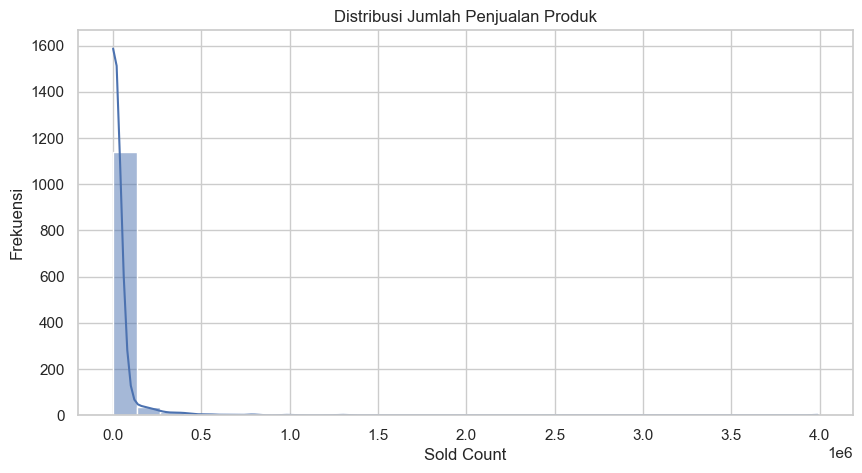

In [96]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["sold_count"],
    bins=30,
    kde=True
)

plt.title("Distribusi Jumlah Penjualan Produk")
plt.xlabel("Sold Count")
plt.ylabel("Frekuensi")

plt.show()

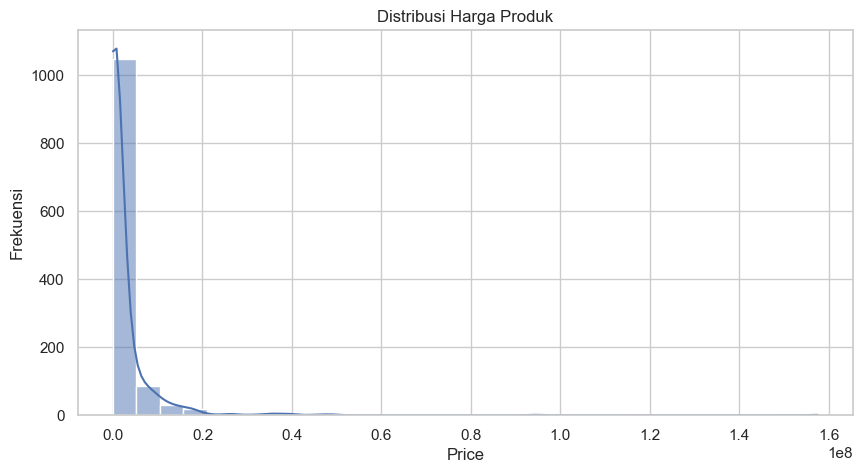

In [97]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Distribusi Harga Produk")
plt.xlabel("Price")
plt.ylabel("Frekuensi")

plt.show()

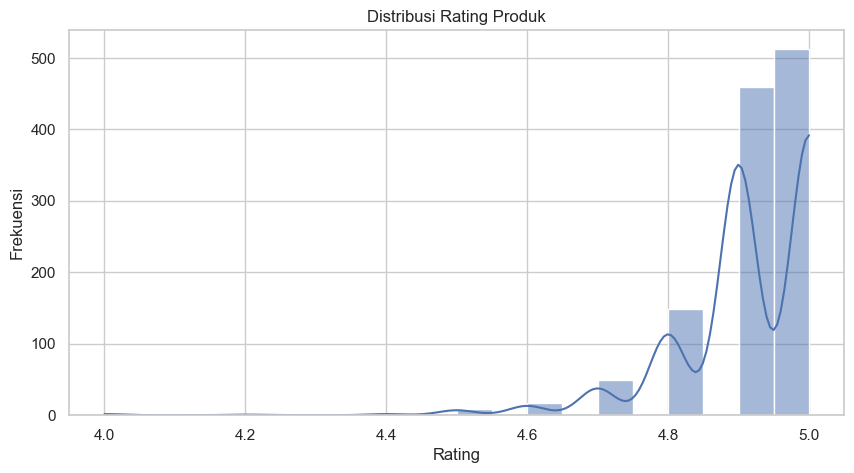

In [98]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["rating"],
    bins=20,
    kde=True
)

plt.title("Distribusi Rating Produk")
plt.xlabel("Rating")
plt.ylabel("Frekuensi")

plt.show()

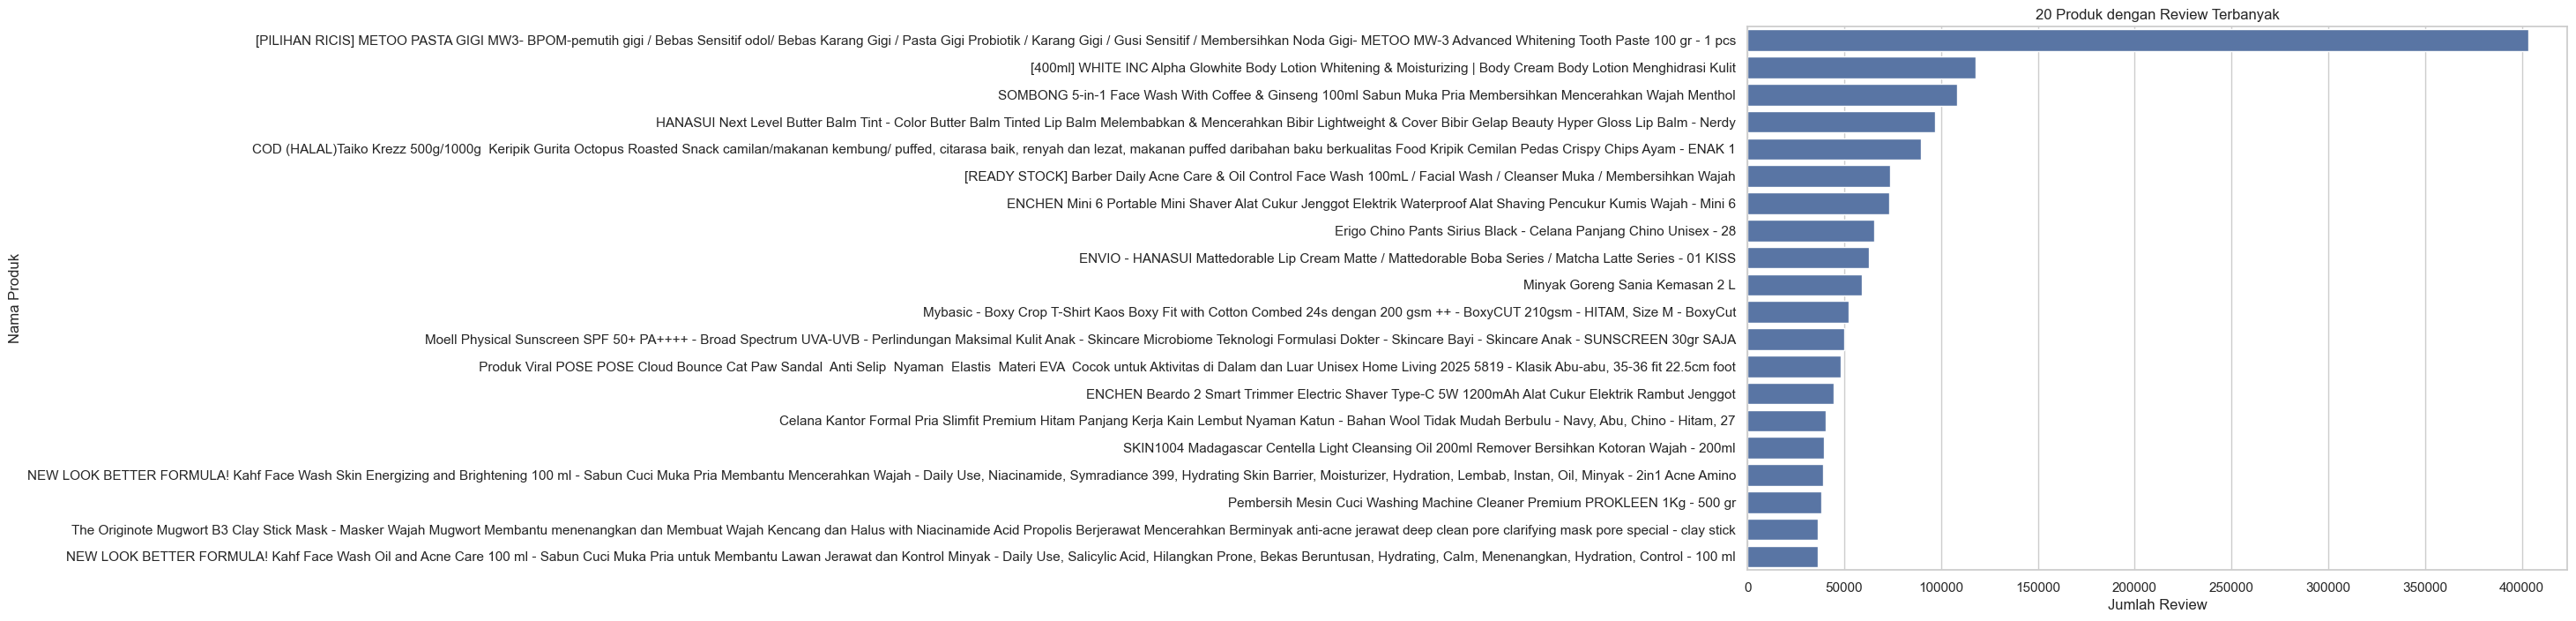

In [99]:
top_review = df.nlargest(
    20,
    "review_count"
)

top_review['name'] = top_review['name'].str.replace('【', '').str.replace('】', '')

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_review,
    x="review_count",
    y="name"
)

plt.title("20 Produk dengan Review Terbanyak")
plt.xlabel("Jumlah Review")
plt.ylabel("Nama Produk")

plt.show()

In [100]:
df["discount_percent"] = (
    df["discount_percent"]
    .fillna("0%")
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)

df = df.dropna(
    subset=[
        "price",
        "discount_percent",
        "review_count",
        "rating",
        "sold_count"
    ]
)

print("Jumlah Data Setelah Cleaning :", len(df))

Jumlah Data Setelah Cleaning : 1200


In [101]:
features = [
    "price",
    "discount_percent",
    "review_count",
    "rating"
]

target = "sold_count"

X = df[features]
y = df[target]

print("Variabel Independen:")
for f in features:
    print("-", f)

print("\nVariabel Dependen:")
print("-", target)

Variabel Independen:
- price
- discount_percent
- review_count
- rating

Variabel Dependen:
- sold_count


In [102]:
corr_matrix = df[
    features + [target]
].corr()

corr_matrix

,price,discount_percent,review_count,rating,sold_count
price,1.000000,-0.146950,-0.087751,0.171902,-0.062931
discount_percent,-0.146950,1.000000,0.123312,-0.241059,0.100551
review_count,-0.087751,0.123312,1.000000,-0.110444,0.952932
rating,0.171902,-0.241059,-0.110444,1.000000,-0.114433
sold_count,-0.062931,0.100551,0.952932,-0.114433,1.000000


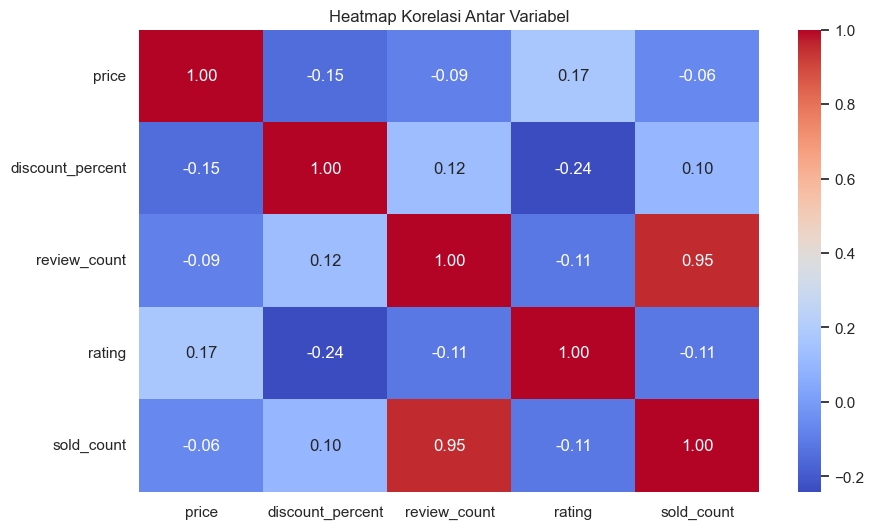

In [103]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heatmap Korelasi Antar Variabel")

plt.show()

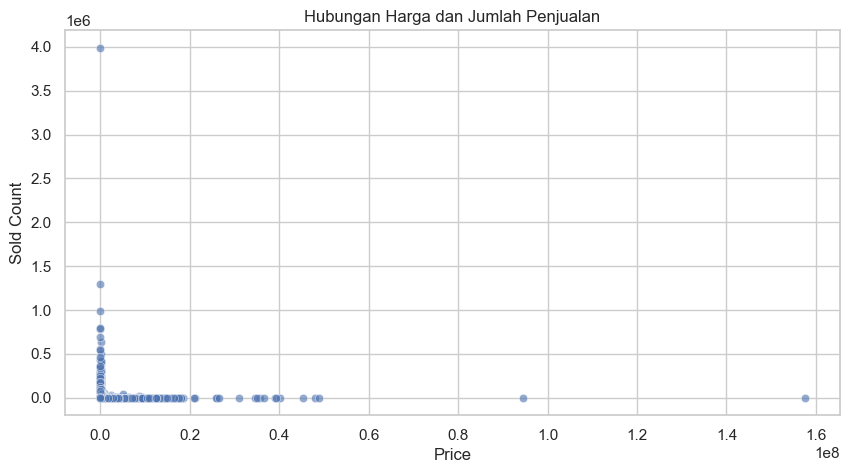

In [104]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="price",
    y="sold_count",
    alpha=0.6
)

plt.title("Hubungan Harga dan Jumlah Penjualan")

plt.xlabel("Price")
plt.ylabel("Sold Count")

plt.show()

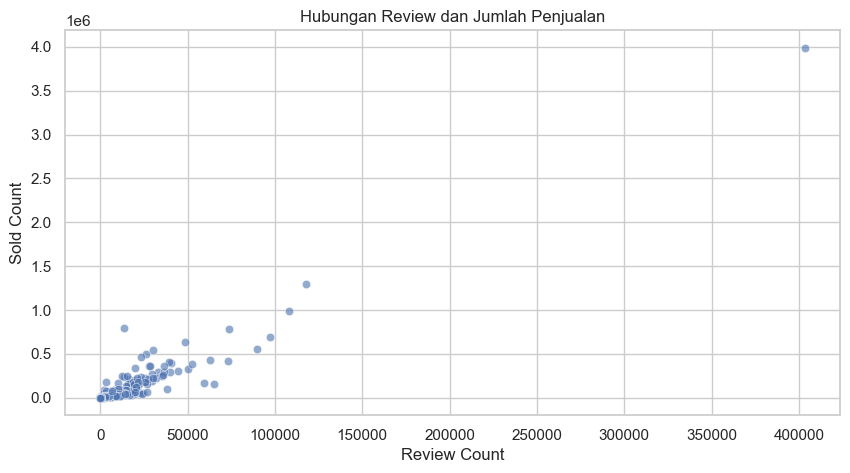

In [105]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="review_count",
    y="sold_count",
    alpha=0.6
)

plt.title("Hubungan Review dan Jumlah Penjualan")

plt.xlabel("Review Count")
plt.ylabel("Sold Count")

plt.show()

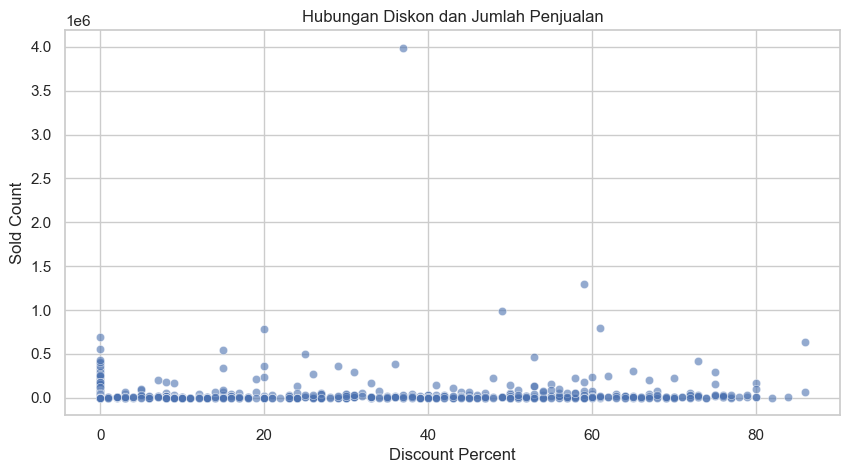

In [106]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="discount_percent",
    y="sold_count",
    alpha=0.6
)

plt.title("Hubungan Diskon dan Jumlah Penjualan")

plt.xlabel("Discount Percent")
plt.ylabel("Sold Count")

plt.show()

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Training :", len(X_train))
print("Data Testing  :", len(X_test))

Data Training : 960
Data Testing  : 240


In [108]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model berhasil dibuat")

Model berhasil dibuat


In [109]:
y_pred = model.predict(X_test)

pd.DataFrame({
    "Aktual": y_test.values[:10],
    "Prediksi": y_pred[:10]
})

,Aktual,Prediksi
0,15,-5902.639581
1,13078,29271.818925
2,3845,3243.016303
3,13558,22109.810610
4,10825,21081.415561
5,1442,-3796.642425
6,2443,3848.989307
7,1,-6088.431681
8,12796,1832.278101
9,4672,3166.373088


In [110]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE  :", round(mae,4))
print("RMSE :", round(rmse,4))
print("R²   :", round(r2,4))

MAE  : 17999.7611
RMSE : 65429.2366
R²   : 0.9396


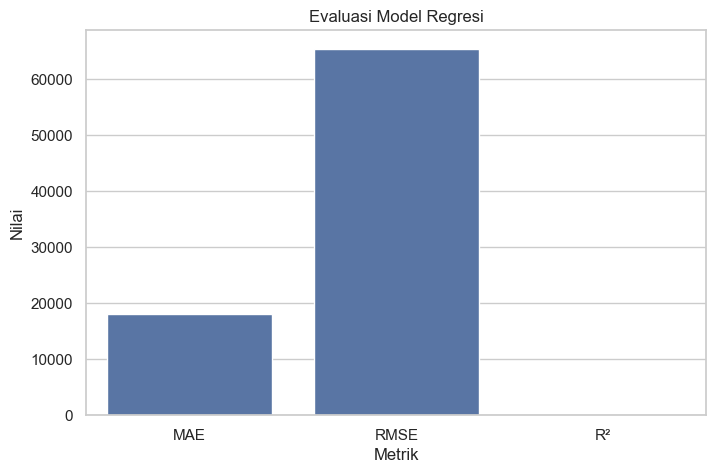

In [111]:
metric_df = pd.DataFrame({
    "Metrik": ["MAE", "RMSE", "R²"],
    "Nilai": [mae, rmse, r2]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=metric_df,
    x="Metrik",
    y="Nilai"
)

plt.title("Evaluasi Model Regresi")

plt.show()

In [112]:
coef_df = pd.DataFrame({
    "Faktor": features,
    "Koefisien": model.coef_
})

coef_df = coef_df.sort_values(
    by="Koefisien",
    ascending=False
)

coef_df

,Faktor,Koefisien
2,review_count,7.730783
3,rating,0.005912
0,price,0.000184
1,discount_percent,-6.209129


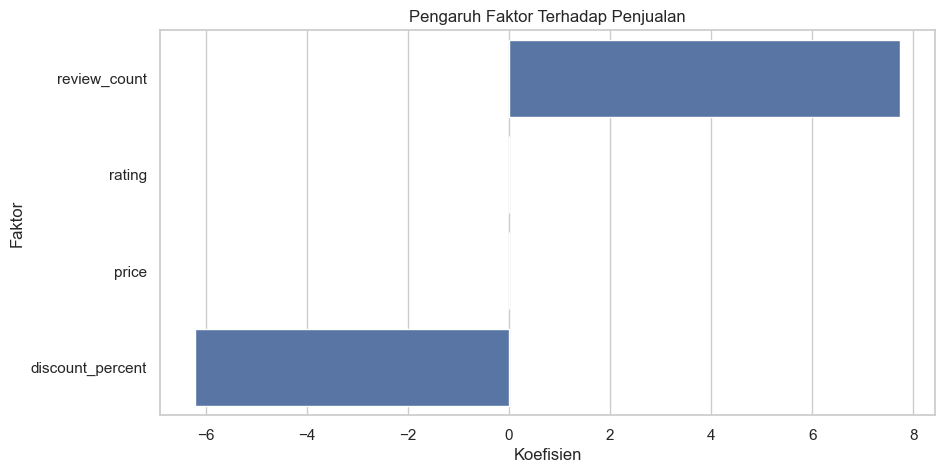

In [113]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=coef_df,
    x="Koefisien",
    y="Faktor"
)

plt.title("Pengaruh Faktor Terhadap Penjualan")

plt.show()

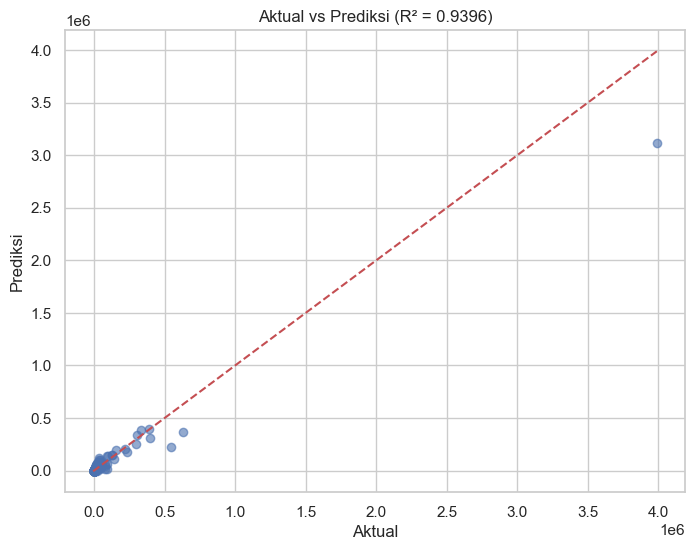

In [114]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

min_val = min(
    y_test.min(),
    y_pred.min()
)

max_val = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_val,max_val],
    [min_val,max_val],
    'r--'
)

plt.title(
    f"Aktual vs Prediksi (R² = {r2:.4f})"
)

plt.xlabel("Aktual")
plt.ylabel("Prediksi")

plt.show()

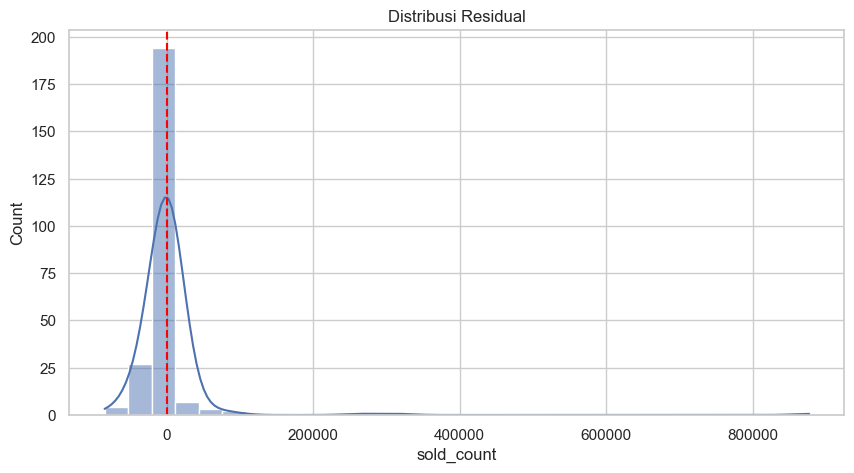

In [115]:
residual = y_test - y_pred

plt.figure(figsize=(10,5))

sns.histplot(
    residual,
    bins=30,
    kde=True
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Distribusi Residual")

plt.show()

In [116]:
print(f"""
KESIMPULAN

Judul:
Analisis Faktor-Faktor yang Mempengaruhi Jumlah Penjualan Produk Tokopedia

Jumlah Data:
{len(df)}

Jumlah Parameter:
{len(features)}

Variabel Independen:
1. Price
2. Discount Percent
3. Review Count
4. Rating

Variabel Dependen:
Sold Count

R²:
{r2:.4f}

Model mampu menjelaskan sekitar
{r2*100:.2f}% variasi jumlah penjualan produk.
""")


KESIMPULAN

Judul:
Analisis Faktor-Faktor yang Mempengaruhi Jumlah Penjualan Produk Tokopedia

Jumlah Data:
1200

Jumlah Parameter:
4

Variabel Independen:
1. Price
2. Discount Percent
3. Review Count
4. Rating

Variabel Dependen:
Sold Count

R²:
0.9396

Model mampu menjelaskan sekitar
93.96% variasi jumlah penjualan produk.

